In [1]:
import pandas as pd
import matplotlib as plt


In [6]:
df = pd.read_csv("final_nexamart.csv")

In [4]:
df.sample(3)

,Order_Id,Customer_Id,Order_Date,Category,Product_Name,Quantity,Unit_Price,Discount_Pct,Payment_Method,Channel,Customer_Age,Customer_Gender,Region,City,Delivery_Days,Rating,Returned,Revenue,Age_Group,Profit
4423,ORD006559,CUST02129,2025-10-08,Sports,Dumbbell_Set,1,1996.71,0.15,Credit_Card,Mobile_App,26,Male,West,Surat,3,5.0,False,1697.2035,Young Adults (18-35),-299.5065
9686,ORD004941,CUST02713,2024-10-10,Home_&_Kitchen,Led_Lamp,2,581.84,0.15,Debit_Card,Website,56,Other,North,Jaipur,8,4.0,False,989.1280,Middle-Aged (36-64),407.2880
3308,ORD006212,CUST01422,2025-11-26,Fashion,Women'S_Kurti,1,920.54,0.05,Debit_Card,Mobile_App,20,Female,South,Chennai,7,4.0,False,874.5130,Young Adults (18-35),-46.0270


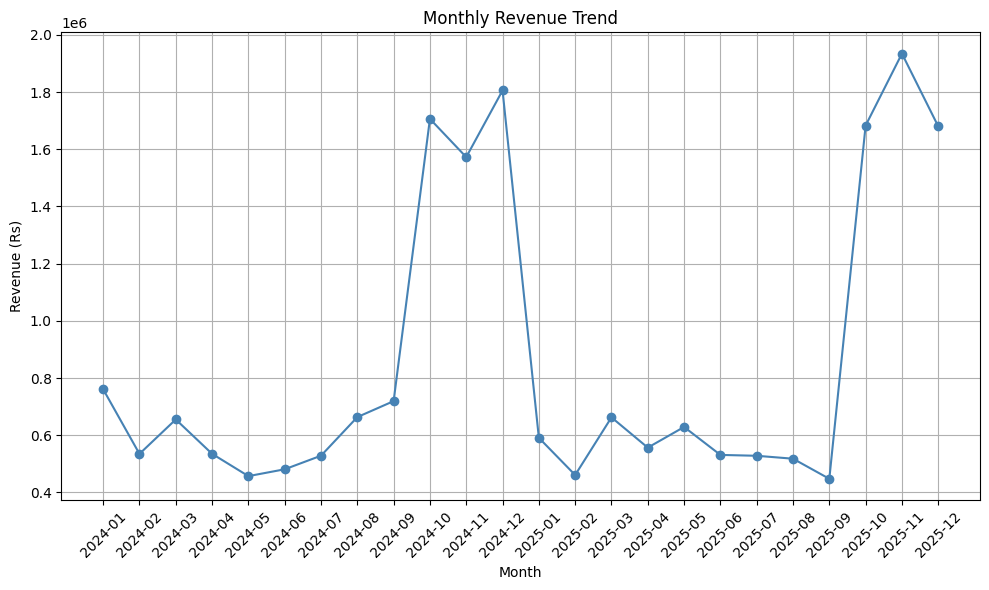

In [7]:
# Ensure Order_Date is datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Group by month directly
monthly_revenue = df.groupby(df['Order_Date'].dt.to_period('M'))['Revenue'].sum().reset_index()

# Convert period to string for plotting
monthly_revenue['Order_Date'] = monthly_revenue['Order_Date'].astype(str)

# Plot
import matplotlib.pyplot as plt
plt.figure(figsize=(10,6))
plt.plot(monthly_revenue['Order_Date'], monthly_revenue['Revenue'], marker='o', color='steelblue')
plt.xticks(rotation=45)
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.grid(True)
plt.tight_layout()
plt.show()


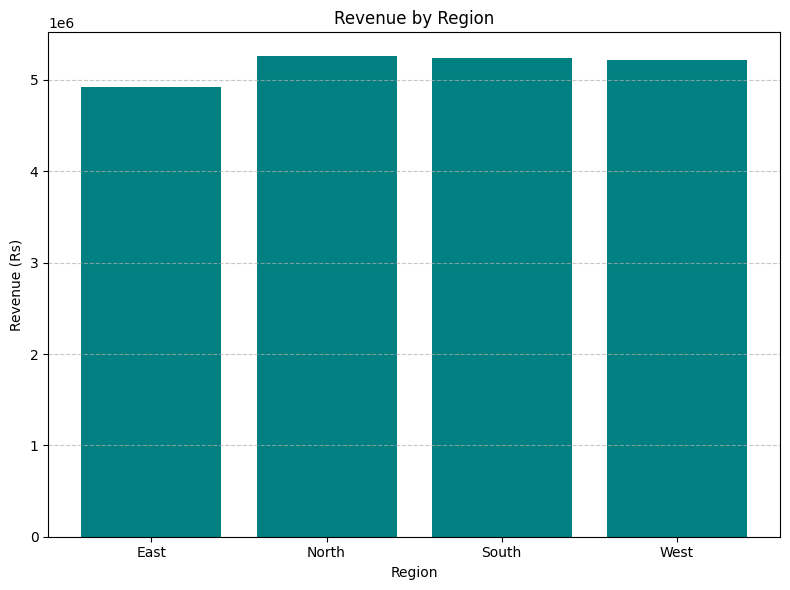

In [8]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by Region and sum Revenue
region_revenue = df.groupby('Region')['Revenue'].sum().reset_index()

# Plot as bar chart
plt.figure(figsize=(8,6))
plt.bar(region_revenue['Region'], region_revenue['Revenue'], color='teal')
plt.title('Revenue by Region')
plt.xlabel('Region')
plt.ylabel('Revenue (Rs)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


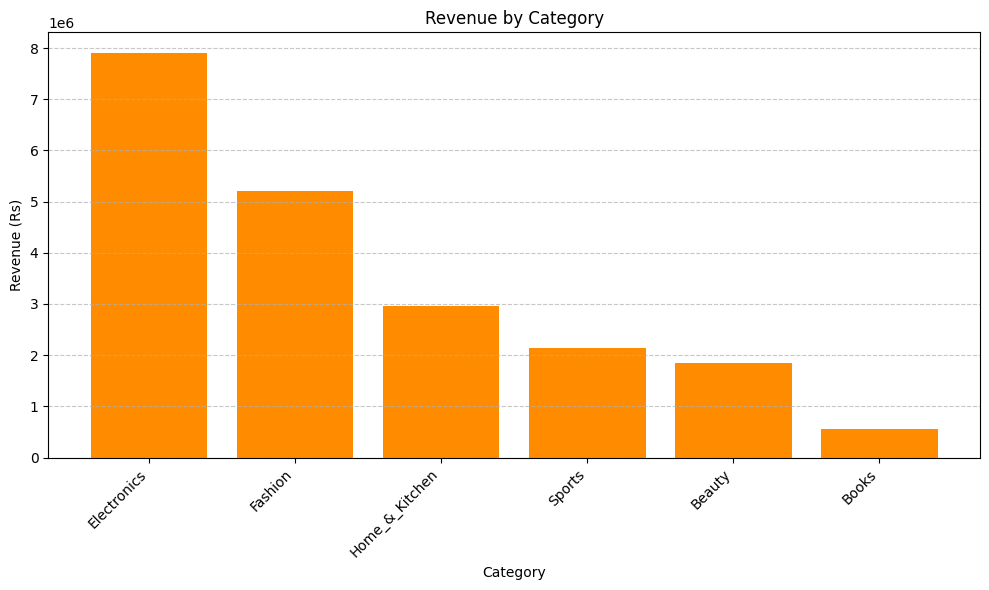

In [9]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by Category and sum Revenue
category_revenue = df.groupby('Category')['Revenue'].sum().reset_index()

# Sort for better readability (optional)
category_revenue = category_revenue.sort_values(by='Revenue', ascending=False)

# Plot as bar chart
plt.figure(figsize=(10,6))
plt.bar(category_revenue['Category'], category_revenue['Revenue'], color='darkorange')
plt.title('Revenue by Category')
plt.xlabel('Category')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


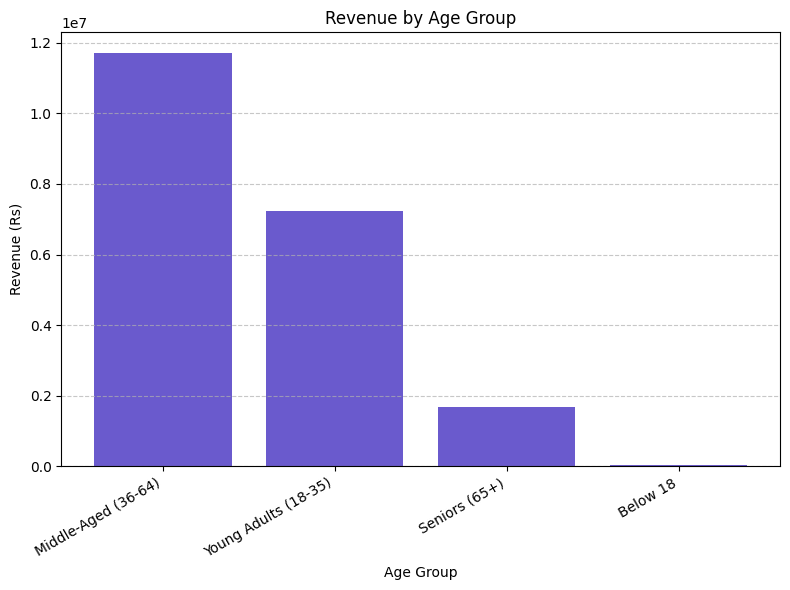

In [10]:
import pandas as pd
import matplotlib.pyplot as plt

# Group by Age_Group and sum Revenue
age_revenue = df.groupby('Age_Group')['Revenue'].sum().reset_index()

# Sort for readability (optional)
age_revenue = age_revenue.sort_values(by='Revenue', ascending=False)

# Plot as bar chart
plt.figure(figsize=(8,6))
plt.bar(age_revenue['Age_Group'], age_revenue['Revenue'], color='slateblue')
plt.title('Revenue by Age Group')
plt.xlabel('Age Group')
plt.ylabel('Revenue (Rs)')
plt.xticks(rotation=30, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()


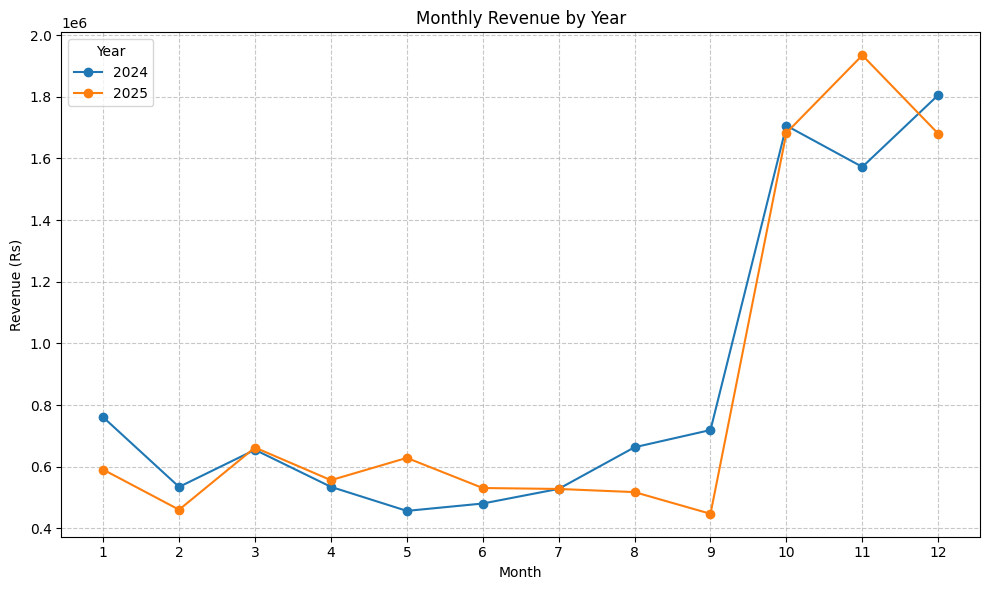

In [11]:
import pandas as pd
import matplotlib.pyplot as plt

# Ensure Order_Date is datetime
df['Order_Date'] = pd.to_datetime(df['Order_Date'])

# Extract Year and Month
df['Year'] = df['Order_Date'].dt.year
df['Month'] = df['Order_Date'].dt.month

# Group by Year and Month
monthly_revenue = df.groupby(['Year','Month'])['Revenue'].sum().reset_index()

# Pivot for plotting: rows = Month, columns = Year
pivot_rev = monthly_revenue.pivot(index='Month', columns='Year', values='Revenue')

# Plot
plt.figure(figsize=(10,6))
for year in pivot_rev.columns:
    plt.plot(pivot_rev.index, pivot_rev[year], marker='o', label=str(year))

plt.title('Monthly Revenue by Year')
plt.xlabel('Month')
plt.ylabel('Revenue (Rs)')
plt.xticks(range(1,13))
plt.legend(title='Year')
plt.grid(True, linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()
